In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
from tqdm import tqdm
jax.config.update("jax_enable_x64", True)

In [2]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  # h = jax.nn.elu(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

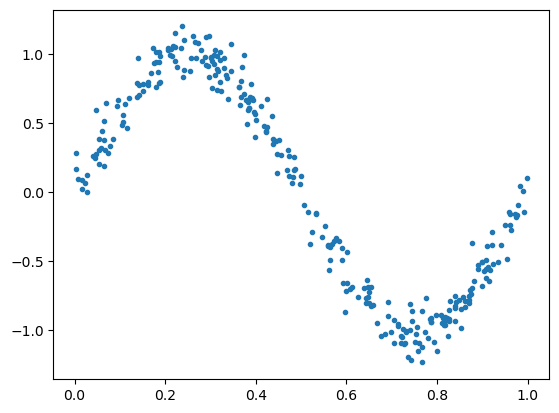

In [3]:
def target_function(z):
  return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]
    Y_clean = target_function(Z)
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y = Y_clean + noise
    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z, Y = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
device = jax.devices()[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

In [4]:
from functools import partial
def log_q0(x, cov=1.):
  return multivariate_normal.logpdf(x, jnp.zeros_like(x), cov)

def L(X, unravel_fn, gamma=100):
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

def gL(X, unravel_fn, gamma):
  Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
  # x = X[0]
  g = jax.grad(lambda x, z: forward(unravel_fn(x), z), 0)
  # print(g(x, Z[0]).shape)
  G = vmap( lambda x: vmap(lambda z: g(x, z))(Z) )(X)
  # print(G.shape)
  diff= ( Y -Esp_forward )[:, None]
  result = vmap(lambda i: (diff * G[i]).mean(axis=0))(jnp.arange(len(X)))
  # print(result.shape)
  return -2*gamma * result

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)

# q0cov = 100.
# log_q0_ = lambda x: log_q0(x, q0cov)
gamma = 1000
L_ = jit(lambda X: L(X, unravel_fn, gamma))
S_q0 = jit(vmap(grad(log_q0)))
# gradL = jit(grad(lambda X : L_(X)* len(X)))
gradL = jit(lambda X : gL(X, unravel_fn, gamma))
score = lambda X: S_q0(X) - gradL(X)

In [5]:
class GradientKernel:
    def __init__(self, S_PQ, k):
        self.S_PQ = S_PQ
        self.k = jit(k)
        self.dkx = jit(jacrev(self.k, argnums=0))
        self.dky = jit(jacrev(self.k, argnums=1))
        self.d2k = jit(jacfwd(self.dky, argnums=0))
        self.K = lambda X : vmap(lambda x: vmap(lambda y: self.k(x, y))(X))(X)
        self.dKx = lambda X : vmap(lambda x: vmap(lambda y: self.dkx(x, y))(X))(X)
        self.d2K = lambda X : vmap(lambda x: vmap(lambda y: jnp.trace(self.d2k(x, y)))(X))(X)


    def evaluate(self, X):
        K = self.K(X)
        dK = self.dKx(X)
        d2K = self.d2K(X)
        S_PQ = self.S_PQ(X)
        S_dK = jnp.einsum('ijk, ijk -> ij', dK, (S_PQ[None, :, :]))
        k_pq = d2K + S_dK + S_dK.T + K * jnp.dot(S_PQ, S_PQ.T)
        return k_pq


def kgd(k_pq, X):
  return k_pq.evaluate(X).mean()

def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)

In [6]:
# Kernels
scale = 1
k = lambda x, y: jnp.exp(-((x-y).dot(x-y)/scale**2))
# k = jit(lambda x, y: k_imq(x/scale, y/scale, 1, 0.5) + x.dot(y))
#k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
# k = lambda x, y: (1 + x.dot(y))**2
k_pq = GradientKernel(score, k)

In [7]:
import flax
from flax import linen as nn

# Pushforward map
class Model(nn.Module):
    hidden_dim: int

    @nn.compact
    def __call__(self, x):
        x_ = x.copy()
        x = nn.Dense(self.hidden_dim)(x)
        x = nn.elu(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = nn.elu(x)
        # z = nn.Dense(self.hidden_dim)(x)
        # x = nn.elu(x)
        x = nn.Dense(d)(x)
        return (x + x_).squeeze()

def l2_norm(params):
    # sum of squared parameters over the whole pytree
    return sum([jnp.sum(jnp.square(p)) for p in jax.tree_util.tree_leaves(params)])

def loss(params, noise, reg=1e+1):
  X = model.apply(params, noise)
  K = k_pq.evaluate(X)
  K_diag = jnp.diag(K)
  # K = K - jnp.diag(K_diag)
  # return L_(X)
  return K.mean()**0.5  # + reg*l2_norm(params)

In [ ]:
model = Model(20)
d_noise = 4

# initialisation
key1, key2 = random.split(random.key(0))
x = random.normal(key1, (d_noise,)) # Dummy input data
params = model.init(key2, x) # Initialization call
jax.tree_util.tree_map(lambda x: x.shape, params) # Checking output shapes
model.apply(params, x)

N = 1000
noise = random.normal(subkey, (N, d_noise))
initial_particles = model.apply(params, noise)

import optax

# learning_rate = 1e-3          # SGD usually needs a bigger LR than Adam; try 1e-2 → 1e-1
# tx = optax.sgd(learning_rate=learning_rate, momentum=0.0)   # momentum=0 → pure GD
# or: tx = optax.sgd(learning_rate=learning_rate, momentum=0.9)  # classic SGD+momentum

learning_rate = 1e-2
tx = optax.adam(learning_rate=learning_rate)

opt_state = tx.init(params)


# Training loop
T = 300
keys = random.split(key, T)
num_particles = 100

losses = []
for step in tqdm(range(T)):
    noise = 10 * random.normal(keys[step], (num_particles, d_noise))
    loss_grad_fn = jax.value_and_grad(lambda params: loss(params, noise))

    loss_value, grads = loss_grad_fn(params)
    updates, opt_state = tx.update(grads, opt_state)
    params = optax.apply_updates(params, updates)


    X = model.apply(params, noise)

    if step % 10 == 0:
      mse = L_(X) / gamma
      gradsize = (gradL(X)**2).sum() / gamma**2
      print(f"Step {step}, Loss: {loss_value}, MSE {mse}, Grad {gradsize}")

    losses.append(loss_value)



  0%|          | 0/300 [00:00<?, ?it/s]

  2%|▏         | 7/300 [00:00<00:09, 30.90it/s]

Step 0, Loss: 1035.2412196918592, MSE 667.5404996909745, Grad 844285.3122734567


  4%|▍         | 12/300 [00:00<00:08, 35.80it/s]

Step 10, Loss: 1452.3810330975082, MSE 71.92814179705707, Grad 57862.05024021802


...

 95%|█████████▌| 286/300 [00:08<00:00, 29.41it/s]

Step 280, Loss: 886.402067812873, MSE 6.877166968174728, Grad 5083.015685274368


 99%|█████████▉| 298/300 [00:08<00:00, 33.39it/s]

Step 290, Loss: 137.87381403028363, MSE 1.2288423036939762, Grad 716.7044233989393


100%|██████████| 300/300 [00:08<00:00, 35.09it/s]


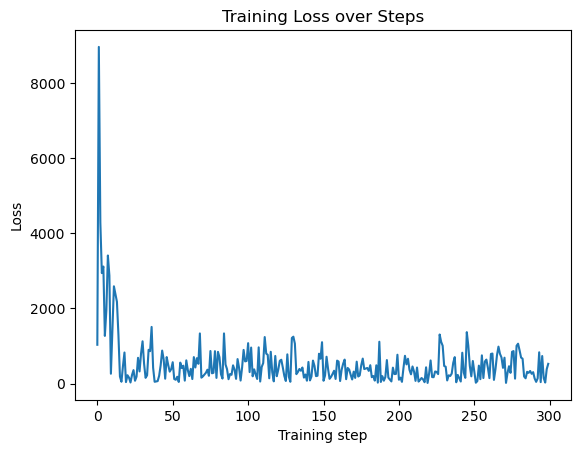

In [18]:
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training Loss over Steps")
plt.show()

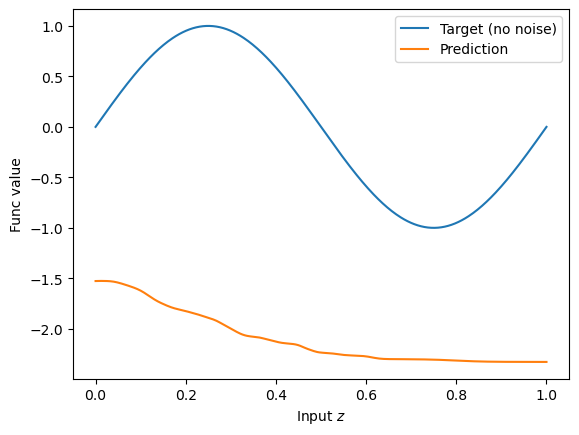

In [19]:
key, subkey = random.split(key)
N = 1000
noise = 10*random.normal(subkey, (N, d_noise))
final_particles = model.apply(params, noise)
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
prediction = vmap(lambda z: forward_(final_particles, z, unravel_fn))(Ztest)

plt.plot(Ztest, target_values, label='Target (no noise)')
plt.plot(Ztest, prediction, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
# plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

In [20]:
gradL(final_particles).std(axis=0)/gamma

Array([2.54097084e-01, 8.55348769e-01, 7.39537959e-01, 9.09494702e-16],      dtype=float64)

In [21]:
gradL(final_particles).mean(axis=0)/gamma

Array([-0.02639999,  4.00593437, -0.08343762, -4.21948293], dtype=float64)

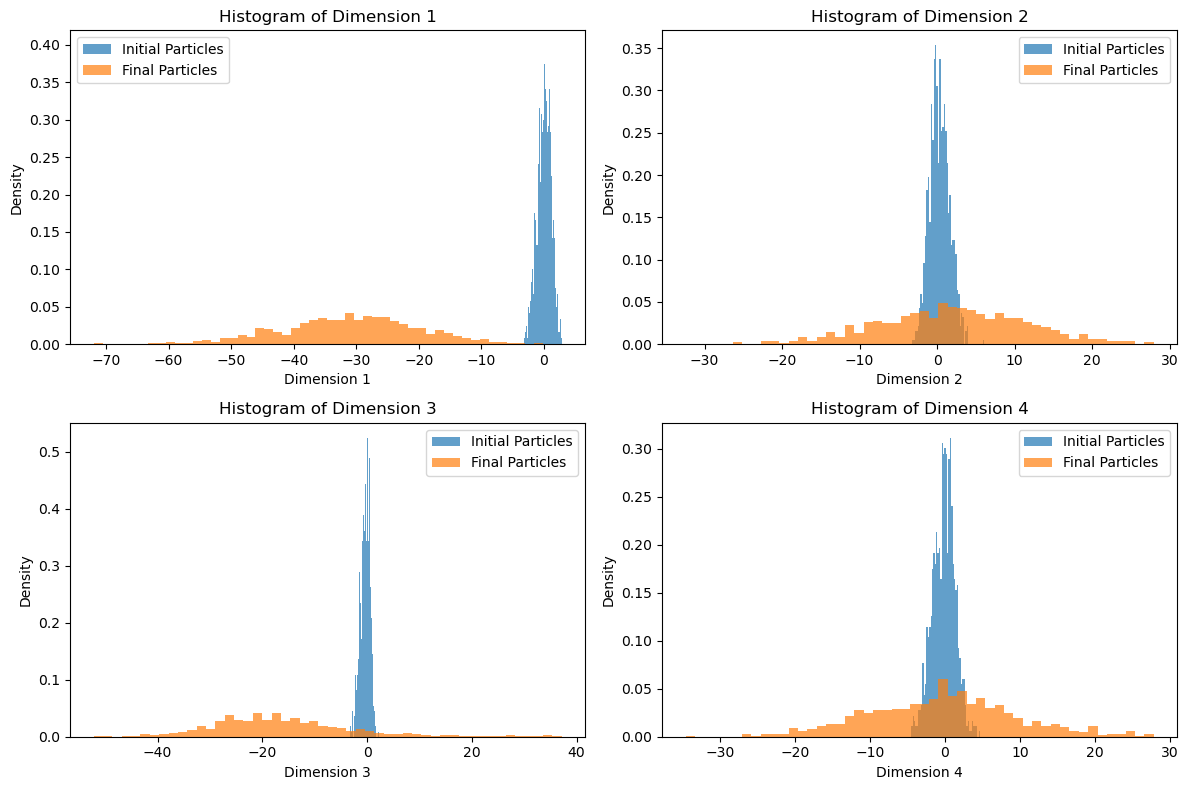

In [22]:
plt.figure(figsize=(12, 8))

for i in range(final_particles.shape[1]):
    plt.subplot(2, 2, i + 1)
    plt.hist(initial_particles[:, i], bins=50, density=True, alpha=0.7, label='Initial Particles')
    plt.hist(final_particles[:, i], bins=50, density=True, alpha=0.7, label='Final Particles')
    plt.xlabel(f'Dimension {i + 1}')
    plt.ylabel('Density')
    plt.title(f'Histogram of Dimension {i + 1}')
    plt.legend()

plt.tight_layout()
plt.show()

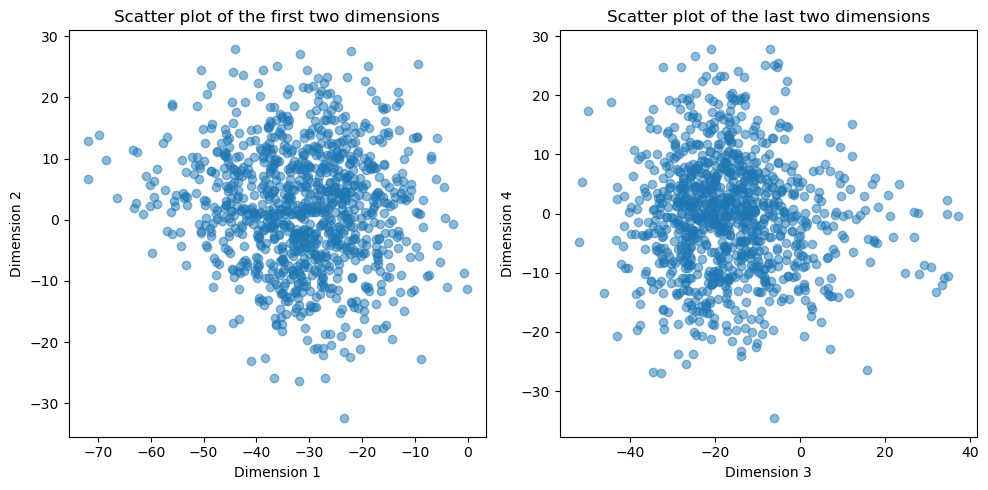

In [23]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(final_particles[:, 0], final_particles[:, 1], alpha=0.5)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Scatter plot of the first two dimensions')
#plt.axis([-10, 10, -10, 10])
plt.subplot(1, 2, 2)
plt.scatter(final_particles[:, 2], final_particles[:, 3], alpha=0.5)
plt.xlabel('Dimension 3')
plt.ylabel('Dimension 4')
plt.title('Scatter plot of the last two dimensions')

#plt.axis([-10, 10, -10, 10])

plt.tight_layout()
plt.show()